In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
!pip install holidays
import holidays

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Processo Seletivo Analytica 2026 - **Grupo L**

# Requisitos
- Identificar linhas de ônibus “deficientes” em horário de pico
- Propor otimizações dessas linhas via remanejamento da frota
- Identificar critérios de remanejamento.
- EXTRA: Cruzar dados das “piores linhas” com os bairros, buscando os bairros mais afetados
- EXTRA: Adicionar dados no modelo preditivo: mm de chuva nas últimas 2/3 horas e o esperado para próxima hora quando o ônibus sair do terminal (fontes: https://datariov2-pcrj.hub.arcgis.com/datasets/25eceb6bd2214fbb8514e9cdf8e1f0f0_1/explore


# Preparação de dados

Para esse problema, realizamos uma busca dentre diversos datasets e encontramos os seguintes dados disponíveis. Abaixo, mostrarei uma visualização de algumas tabelas de dados.

**Fonte extra de dados**: https://www.data.rio/documents/transporte-rodovi%C3%A1rio-viagens-dos-%C3%B4nibus-identificadas-por-gps/about e https://github.com/prefeitura-rio/queries-rj-smtr/tree/master/models/projeto_subsidio_sppo

# **OBS**:
Para visualizar outras tabelas csv nos códigos abaixo, basta substituir a string dentro de `caminho_dado` pelo caminho do arquivo que se deseja visualizar. Todos os arquivos utilizados estão na pasta `/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL`. Assim que tiver o e-mail de vocês, eu compartilho ela no drive.

## SMTR — Sistema Municipal de Transportes

Dados operacionais, financeiros e estruturais do sistema de transporte público do Rio de Janeiro. Filtrei alguns dados e, abaixo, segue a visualização de alguns que se mostraram mais relevantes para atender os requisitos.

### dashboard_bilhetagem_implantacao_jae
Monitoramento GPS Descrição: Dados agregados de localização de veículos por modal:

- BRT
- Ônibus (SPPO)
- Vans (STPL)
- VLT




In [39]:


caminho_dado = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/dashboard_bilhetagem_implantacao_jae-20260430T211213Z-3-001/dashboard_bilhetagem_implantacao_jae/gps_agregado_onibus.csv"
df = pd.read_csv(caminho_dado)
display(df.iloc[1000:1250])
print((df['estado_equipamento'] == 'FECHADO').sum())
print(df.shape)
df.info()
df.describe()


,operadora,id_validador,latitude,longitude,data,estado_equipamento,primeiro_datetime_gps,ultimo_datetime_gps,qtde_min_entre_a_prim_e_ultima_transmissao,qtde_min_distintos_houve_transmissao,qtde_registros_gps,qtde_registros_gps_georreferenciados,percentual_registros_gps_georreferenciados,percentual_transmissao_a_cada_min
1000,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00201540,-22.862547,-43.535267,2026-04-26,FECHADO,2026-04-26 00:00:41.353276,2026-04-26 00:04:41.276823,5,5,5,5,1.0,1.0
1001,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00207133,-22.861964,-43.534204,2026-04-26,FECHADO,2026-04-26 00:00:56.947831,2026-04-26 00:04:57.128333,5,5,5,5,1.0,1.0
1002,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00201108,-22.875594,-43.419609,2026-04-26,FECHADO,2026-04-26 00:00:55.363123,2026-04-26 00:04:55.566801,5,5,5,5,1.0,1.0
1003,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00206504,-22.875836,-43.420003,2026-04-26,FECHADO,2026-04-26 00:00:43.229766,2026-04-26 00:04:43.046377,5,5,5,5,1.0,1.0
1004,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00207625,-22.876585,-43.419500,2026-04-26,FECHADO,2026-04-26 00:00:47.126782,2026-04-26 00:04:47.063856,5,5,5,5,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,TRANSPORTES FUTURO LTDA,B35T020D00205494,-22.951309,-43.348345,2026-04-26,FECHADO,2026-04-26 00:00:52.336561,2026-04-26 00:04:52.286387,5,5,5,5,1.0,1.0
1246,TRANSPORTES FUTURO LTDA,B35T020D00203417,-22.950718,-43.348123,2026-04-26,FECHADO,2026-04-26 00:00:00.877725,2026-04-26 00:04:00.498694,5,5,5,5,1.0,1.0
1247,TRANSPORTES FUTURO LTDA,B35T020D00205078,-22.949744,-43.348325,2026-04-26,FECHADO,2026-04-26 00:00:07.511207,2026-04-26 00:04:07.662445,5,5,5,5,1.0,1.0
1248,TRANSPORTES FUTURO LTDA,B35T020D00210641,-22.951169,-43.348440,2026-04-26,FECHADO,2026-04-26 00:00:06.135282,2026-04-26 00:04:05.844671,5,5,5,5,1.0,1.0


3057
(3057, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3057 entries, 0 to 3056
Data columns (total 14 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   operadora                                   3057 non-null   object 
 1   id_validador                                3057 non-null   object 
 2   latitude                                    3057 non-null   float64
 3   longitude                                   3057 non-null   float64
 4   data                                        3057 non-null   object 
 5   estado_equipamento                          3057 non-null   object 
 6   primeiro_datetime_gps                       3057 non-null   object 
 7   ultimo_datetime_gps                         3057 non-null   object 
 8   qtde_min_entre_a_prim_e_ultima_transmissao  3057 non-null   int64  
 9   qtde_min_distintos_houve_transmissao        3057 non-null   int64  
 

,latitude,longitude,qtde_min_entre_a_prim_e_ultima_transmissao,qtde_min_distintos_houve_transmissao,qtde_registros_gps,qtde_registros_gps_georreferenciados,percentual_registros_gps_georreferenciados,percentual_transmissao_a_cada_min
count,3057.000000,3057.000000,3057.000000,3057.000000,3057.000000,3057.000000,3057.000000,3057.000000
mean,-22.751618,-43.087552,4.993458,4.989859,4.997383,4.969251,0.994374,0.999182
std,1.752197,3.318828,0.092006,0.126219,0.076702,0.379924,0.074460,0.013693
min,-24.461542,-47.817994,2.000000,2.000000,2.000000,0.000000,0.000000,0.750000
25%,-22.949964,-43.368689,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000
50%,-22.877602,-43.348573,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000
75%,-22.858282,-43.292395,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000
max,0.000000,0.000000,5.000000,5.000000,6.000000,6.000000,1.000000,1.000000


### gtfs
Base padronizada de transporte contendo:
- routes: linhas
- stops: paradas(id das paradas e localização). 485884 linhas
- trips: viagens (onibus, id das rotas e direção) 556360 linhas
- shapes: geometria das rotas (ponto de inicio/fim e formato). 13946 linhas. **aponta para shape**
- calendar + calendar_dates: operação temporal (obras, dias da semana, dia de inicio e término). 923 linhas e 34225 linhas
- ordem_servico: onibus, horarios de funcionamento, tamanho do trajedo ida/volta, total viagens ida/volta (dado o dia da semana) 113629 linhas
- frequencies: contém o intervalo entre um onibus e outro, delimitado pela prefeitura




In [40]:

caminho_dado = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/ordem_servico.csv"
df = pd.read_csv(caminho_dado)
display(df.iloc[1:120])
print(df.shape)
df.info()
df.describe()


,feed_version,feed_start_date,feed_end_date,tipo_os,servico,vista,consorcio,horario_inicio,horario_fim,extensao_ida,extensao_volta,partidas_ida,partidas_volta,viagens_planejadas,distancia_total_planejada,tipo_dia,versao_modelo
1,2024-09-01,2024-09-01,2024-09-12,Regular,SN353,Gardênia Azul - Terminal Gentileza,Transcarioca,00:00:00,05:20:00,31.981,32.103,4.0,4.0,4.0,256.34,Domingo,43b43fa561a2ae17398e297665179228b77f64aa
2,2024-09-01,2024-09-01,2024-09-12,Regular,SN353,Gardênia Azul - Terminal Gentileza,Transcarioca,00:00:00,05:20:00,31.981,32.103,4.0,4.0,4.0,256.34,Ponto Facultativo,43b43fa561a2ae17398e297665179228b77f64aa
3,2024-09-01,2024-09-01,2024-09-12,Regular,SN353,Gardênia Azul - Terminal Gentileza,Transcarioca,00:00:00,05:20:00,31.981,32.103,4.0,4.0,4.0,256.34,Sabado,43b43fa561a2ae17398e297665179228b77f64aa
4,2024-09-01,2024-09-01,2024-09-12,Regular,SN554,Piabas - Rio Sul,Transcarioca,00:00:00,04:45:00,57.649,52.886,3.0,3.0,3.0,331.60,Dia Útil,43b43fa561a2ae17398e297665179228b77f64aa
5,2024-09-01,2024-09-01,2024-09-12,Regular,SN554,Piabas - Rio Sul,Transcarioca,00:00:00,04:45:00,57.649,52.886,3.0,3.0,3.0,331.60,Ponto Facultativo,43b43fa561a2ae17398e297665179228b77f64aa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-09-01,2024-09-01,2024-09-12,Regular,790,Campo Grande - Cascadura,Santa Cruz,02:40:00,24:05:00,32.266,35.252,85.0,85.0,85.0,5739.03,Dia Útil,43b43fa561a2ae17398e297665179228b77f64aa
116,2024-09-01,2024-09-01,2024-09-12,Regular,LECD96,Metrô Botafogo - Terminal Alvorada,Intersul,02:45:00,26:41:00,23.248,23.052,83.0,77.0,80.0,3704.59,Domingo,43b43fa561a2ae17398e297665179228b77f64aa
117,2024-09-01,2024-09-01,2024-09-12,Regular,LECD96,Metrô Botafogo - Terminal Alvorada,Intersul,02:45:00,26:41:00,23.248,23.052,79.0,79.0,79.0,3657.70,Ponto Facultativo,43b43fa561a2ae17398e297665179228b77f64aa
118,2024-09-01,2024-09-01,2024-09-12,Regular,LECD96,Metrô Botafogo - Terminal Alvorada,Intersul,02:45:00,26:41:00,23.248,23.052,126.0,126.0,126.0,5833.80,Dia Útil,43b43fa561a2ae17398e297665179228b77f64aa


(113629, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113629 entries, 0 to 113628
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   feed_version               113629 non-null  object 
 1   feed_start_date            113629 non-null  object 
 2   feed_end_date              89107 non-null   object 
 3   tipo_os                    113629 non-null  object 
 4   servico                    113629 non-null  object 
 5   vista                      113629 non-null  object 
 6   consorcio                  113629 non-null  object 
 7   horario_inicio             113629 non-null  object 
 8   horario_fim                113629 non-null  object 
 9   extensao_ida               113629 non-null  float64
 10  extensao_volta             113629 non-null  float64
 11  partidas_ida               101583 non-null  float64
 12  partidas_volta             101583 non-null  float64
 13  viagens_planejad

,extensao_ida,extensao_volta,partidas_ida,partidas_volta,viagens_planejadas,distancia_total_planejada
count,113629.000000,113629.000000,101583.000000,101583.000000,101665.000000,113629.000000
mean,124.871270,102.790457,34.688570,31.928443,34.199262,1503.240623
std,1626.191405,1434.117566,45.390555,44.218406,44.914274,2101.888484
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.445000,11.693000,2.000000,0.000000,2.000000,69.940000
50%,22.763000,21.425000,20.000000,15.000000,19.500000,597.480000
75%,30.268000,29.072000,50.000000,48.000000,49.500000,2099.080000
max,60232.000000,58052.000000,541.000000,541.000000,541.000000,24499.620000


### br_rj_riodejaneiro_viagem_zirix
**TABELA CENTRAL**

Dados
- Horas de inicio e chegada de cada linha
- **Aponta para o shape id, veículo e número da linha**

Útil para calcular a duração de cada viagem dada a hora, que pode servir para criar um modelo preditivo que alimenta possíveis cálculos de

```
# Isto está formatado como código
```

otimizações.





In [41]:

caminho_dado = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/br_rj_riodejaneiro_viagem_zirix-20260430T211251Z-3-001/br_rj_riodejaneiro_viagem_zirix/viagem_informada.csv"
df = pd.read_csv(caminho_dado)
display(df.iloc[250000:251000])
print(df.shape)
df.info()
df.describe()


,data,datetime_partida,datetime_chegada,datetime_processamento,datetime_captura,id_veiculo,trip_id,route_id,shape_id,servico,sentido,id_viagem,versao,datetime_ultima_atualizacao
250000,2026-01-20,2026-01-20 11:00:35,2026-01-20 12:09:09,2026-01-20 12:09:11,2026-01-20 12:20:00,C47460,NaN,O0600AAA0A,v5ag,600,Ida,C47460_600_I_v5ag_20260120110035,c8f981ff13a7041f80169be5b2369842ed133f44,2026-02-25 01:32:42.050288
250001,2026-02-09,2026-02-09 05:38:16,2026-02-09 07:08:46,2026-02-09 07:08:47,2026-02-09 07:20:00,B28576,NaN,O0696AAA0A,68r3,696,Ida,B28576_696_I_68r3_20260209053816,56971229e42ea72637cf282697b64c6dbb6e46b8,2026-02-13 02:32:37.737633
250002,2025-08-14,2025-08-14 21:30:37,2025-08-14 21:59:43,2025-08-14 21:59:44,2025-08-14 22:10:00,A71561,NaN,O0100AAA0A,ffdt,100,Ida,A71561_100_I_ffdt_20250814213037,4044fd38a325410e15a38d1d2c6934da1edca9c7,2025-08-20 01:33:18.142929
250003,2025-03-10,2025-03-10 22:42:34,2025-03-10 23:59:22,2025-03-10 23:59:24,2025-03-11 00:10:00,D86279,NaN,O0853AAA0A,ks4m,853,Volta,D86279_853_V_ks4m_20250310224234,79dec47dac806bca7f59d4b97eabc3692820bb75,2025-03-12 01:34:30.808188
250004,2024-06-10,2024-06-10 02:13:45,2024-06-10 02:45:18,2024-06-10 02:45:19.43,2024-06-10 03:00:00,D17173,NaN,O0885AAA0A,g6hc,885,Ida,583821,21fb978ff4944269e241422bb986837a672c6084,2024-06-27 09:13:26.1124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250995,2025-01-24,2025-01-24 17:07:29,2025-01-24 17:55:30,2025-01-24 17:55:34,2025-01-24 18:10:00,D86052,NaN,O0838AAA0A,1032,838,Volta,D86052_838_V_1032_20250124170729,7ce1da121234cacf2ee4801c2433c70ee7f5ecf6,2025-02-11 01:32:45.702863
250996,2025-06-22,2025-06-22 08:13:57,2025-06-22 08:38:45,2025-06-22 08:43:24,2025-06-22 08:50:00,D86208,NaN,O0802AAA0A,O0802AAA0AVDU01,802,Ida,D86208_802_I_O0802AAA0AVDU01_20250622081357,f31b7674c055a63183eaf0a1a103a346ef44601f,2025-06-26 01:32:54.442597
250997,2025-05-19,2025-05-19 04:38:09,2025-05-19 04:58:09,2025-05-19 04:58:09,2025-05-19 05:10:00,D17129,NaN,O0833AAA0A,O0833AAA0AVDU02,833,Volta,D17129_833_V_O0833AAA0AVDU02_20250519043809,cc50861a74f77d8a2a4cc8834cee2365cb35c93b,2025-05-24 01:32:13.123347
250998,2026-02-05,2026-02-05 21:03:54,2026-02-05 22:00:35,2026-02-05 22:00:36,2026-02-05 22:10:00,B25602,NaN,O0606AAV0A,2bl8,SV606,Ida,B25602_SV606_I_2bl8_20260205210354,8df7635a5781e2e43ecc1920667b18f29516caa0,2026-02-10 01:32:29.913426


(256725, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256725 entries, 0 to 256724
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   data                         256725 non-null  object 
 1   datetime_partida             256725 non-null  object 
 2   datetime_chegada             256725 non-null  object 
 3   datetime_processamento       256725 non-null  object 
 4   datetime_captura             256725 non-null  object 
 5   id_veiculo                   256436 non-null  object 
 6   trip_id                      0 non-null       float64
 7   route_id                     255722 non-null  object 
 8   shape_id                     254861 non-null  object 
 9   servico                      256725 non-null  object 
 10  sentido                      256725 non-null  object 
 11  id_viagem                    256725 non-null  object 
 12  versao                       256725 non-null 

,trip_id
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


### veiculo
Dados dos veículos do sistema:

- Licenciamento: id de veículo, data da última vistoria, tecnologia, id chassi. 222625 linhas.
- solicitação de licenciamento: solicitações realizadas. Acredito que não está no escopo
- registro agente verao: Acredito que não está no escopo
# - Operação diária
- Inspeções
- Condições operacionais

In [42]:
"""
caminho_dado = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/veiculo-20260430T211305Z-3-001/veiculo/sppo_veiculo_dia.csv"
df = pd.read_csv(caminho_dado)
display(df.iloc[1:120])
print(df.shape)
df.info()
df.describe()
"""

'\ncaminho_dado = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/veiculo-20260430T211305Z-3-001/veiculo/sppo_veiculo_dia.csv"\ndf = pd.read_csv(caminho_dado)\ndisplay(df.iloc[1:120])\nprint(df.shape)\ndf.info()\ndf.describe()\n'

# Solução proposta

Com base nos dados acima, iremos analisar os dados para aplicar otimizações na quantidade de veículos por linha de ônibus. O objetivo é diminuir o tempo de espera dos passageiros por linha de ônibus.

Utilizaremos o o intervalo `headway_secs` de início de linha delimitado pela prefeitura na tabela `frequencies.csv` do `gtfs` e, com ele, definiremos que o intervalo médio de espera em um ponto é `headway_secs`/2

(Necessário embasar essa conta acima, sei que ela vem de probabilidade se a gente considerar que ass pessoas chegam nos pontos de forma uniforme e aleatória.)

Em adição, criaremos um modelo preditivo que receberá o tempo de viagem descrito na tabela `viagem_informada.csv` do dataset `br_rj_riodejaneiro_viagem_zirix`, em adição da linha, sentido, horário e dia da semana. O modelo deverá ser  capaz de prever a duração da viagem em qualquer horário e dia futuro.

(Ainda não sei se uma regressão polinomial para cada uma das linhas vai servir para descrever esse tempo de deslocamento dado a hora e dia)

Uniremos os dados de tempo de viagem e intervalo médio nos pontos e, com isso, calcularemos a quantidade de ônibus necessários que essa linha deve possuir naquele momento para cumprir o intervalo médio.

Podemos realizar uma análise dos dados fornecidos e indicar o atraso médio por linha e informações similares, demonstrando a necessidade da nossa aplicação.

Se sobrar tempo, podemos melhorar o modelo para realocar ônibus entre as linhas de forma dinâmica durante o dia, para servir de apoio a secretaria de transportes e empresas de ônibus.

(falta adicionar um tempo de repouso na conta)
(falta embasar esse problema - má distribuição de frota de onibus rj)

## Limitações
Para um primeiro momento, vou considerar que o tempo de deslocamento entre os pontos de ônibus é constante e uniforme. Sei que é uma suposição que foge da realidade do problema, mas, se mostra necessária por conta do trabalho computacional na coleta, tratamento e análise exploratória de milhões de linhas de dados de GPS de ônibus, que devem ser cruzados com a localização das paradas para calcular o deslocamento entre um ponto e outro.

Além disso, com os dados de GPS, seria possível otimizar o modelo para estimar o deslocamento entre trechos da rota com todas as linhas que cruzam esses trechos, sem se limitar a uma análise que considera apenas os ônibus da mesma linha.

Com essa análise por trecho, seria possível aprimorar o modelo para evitar o efeito sanfona (quando os ônibus colam um atrás do outro e chegam juntos no mesmo ponto)





#Dados necessários para o modelo preditivo

1. frequencies.csv (GTFS)
	1. start_time e end_time. Dados sobre hora do dia que a regra abaixo deve valer
	2. headway_secs . Tempo que um ônibus leva para chegar no mesmo ponto que um ônibus acabou de passar (usado para conta de ônibus em linha)
	3. trip_id. Id da viagem. Identifica o dado com a viagem
2. trips.csv(GTFS)
	1. trips_id. Utilizado para dar merge com a tabela acima
	2. trip_short_name: Nome da linha (ex: 324)
	3. direction_id: Direção ida ou volta.
3. ordem_servico_csv (GTFS)
	1. servico (cruzar com viagens_informadas
	2. tamanho da rota ida/tamanho da rota volta
4. viagem_informada.csv (br_rj_riodejaneiro_viagem_zirix-20260430T211251Z-3-001/br_rj_riodejaneiro_viagem_zirix)
	1. servico: será usada para cruzar com trip_short)name da tabela acima
	2. sentido: Teremos que levar em consideração a Ida e Volta da linha, para cruzar com 0 ou 1 do direction_id da tabela acima. No caso, Ida = 0 e Volta = 1
	3. datetime_partida e datetime_chegada: Usados para calcular o tempo de duração de uma viagem de ônibus

O objetivo é juntar todos os dados acima em uma única tabela, para facilitar a manipulação de dados. Porém, antes de uni-las, é importante tratar valores nulos, inválidos e outliers. Segue abaixo o algoritmo que busca por essas situações.

# Limpeza básica de dados com análise exploratória simples

In [43]:


caminho_frequencies = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/frequencies.csv"
caminho_trips = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/trips.csv"
caminho_viagem = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/br_rj_riodejaneiro_viagem_zirix-20260430T211251Z-3-001/br_rj_riodejaneiro_viagem_zirix/viagem_informada.csv"

caminhos = [caminho_frequencies, caminho_trips, caminho_viagem]

for caminho in caminhos:
  df = pd.read_csv(caminho)
  display(df.isnull().sum())
  df.info()

,0
feed_version,0
feed_start_date,0
feed_end_date,5455
trip_id,0
start_time,0
end_time,0
headway_secs,0
exact_times,0
versao_modelo,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484555 entries, 0 to 484554
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   feed_version     484555 non-null  object
 1   feed_start_date  484555 non-null  object
 2   feed_end_date    479100 non-null  object
 3   trip_id          484555 non-null  object
 4   start_time       484555 non-null  object
 5   end_time         484555 non-null  object
 6   headway_secs     484555 non-null  int64 
 7   exact_times      484555 non-null  int64 
 8   versao_modelo    484555 non-null  object
dtypes: int64(2), object(7)
memory usage: 33.3+ MB


,0
feed_version,0
feed_start_date,0
feed_end_date,5907
route_id,0
service_id,0
trip_id,0
trip_headsign,452
trip_short_name,0
direction_id,9
block_id,556360


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556360 entries, 0 to 556359
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   feed_version           556360 non-null  object 
 1   feed_start_date        556360 non-null  object 
 2   feed_end_date          550453 non-null  object 
 3   route_id               556360 non-null  object 
 4   service_id             556360 non-null  object 
 5   trip_id                556360 non-null  object 
 6   trip_headsign          555908 non-null  object 
 7   trip_short_name        556360 non-null  object 
 8   direction_id           556351 non-null  float64
 9   block_id               0 non-null       float64
 10  shape_id               556359 non-null  object 
 11  wheelchair_accessible  0 non-null       float64
 12  bikes_allowed          0 non-null       float64
 13  versao_modelo          556360 non-null  object 
dtypes: float64(4), object(10)
memory usa

,0
data,0
datetime_partida,0
datetime_chegada,0
datetime_processamento,0
datetime_captura,0
id_veiculo,289
trip_id,256725
route_id,1003
shape_id,1864
servico,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256725 entries, 0 to 256724
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   data                         256725 non-null  object 
 1   datetime_partida             256725 non-null  object 
 2   datetime_chegada             256725 non-null  object 
 3   datetime_processamento       256725 non-null  object 
 4   datetime_captura             256725 non-null  object 
 5   id_veiculo                   256436 non-null  object 
 6   trip_id                      0 non-null       float64
 7   route_id                     255722 non-null  object 
 8   shape_id                     254861 non-null  object 
 9   servico                      256725 non-null  object 
 10  sentido                      256725 non-null  object 
 11  id_viagem                    256725 non-null  object 
 12  versao                       256725 non-null  object 
 13 

Existem 9 linhas em trips.csv que possuem valores nulos para o sentido da viagem. Abaixo veremos quais linhas são essas:

In [44]:
df = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/trips.csv")
display(df[df['direction_id'].isnull()])

,feed_version,feed_start_date,feed_end_date,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed,versao_modelo
50608,2023-07-16,2023-07-16,2023-07-31,O0936AAA0A,U_REG,3130cc51-0e07-4acd-a869-9010b20fd8eb,Cidade Unviersitária,936,NaN,NaN,3wry,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
109945,2025-12-21,2025-12-21,2025-12-26,O0298AAE0A,U_REG,200199e4-20ff-4c26-9c5b-34754bd0de2b,Botafogo [alternativo],SE298,NaN,NaN,eeu0,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
130142,2025-12-21,2025-12-21,2025-12-26,O0298AAE0A,U_REG,54c5f495-01c2-4f12-9aa0-4e057d49e9eb,Botafogo [reveillon],SE298,NaN,NaN,b4vf,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
152990,2025-12-21,2025-12-21,2025-12-26,O0169AAE0A,U_REG,3ce995d2-d187-4e0f-ade5-d1aa4ae75ae3,Botafogo [reveillon],SE169,NaN,NaN,ebjm,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
211615,2023-03-01,2023-03-01,2023-03-15,O0601AAP0A,D,29746496-fb8e-4138-bf10-8f86ae189735,Hospital Cardoso Fontes,SP601,NaN,NaN,u8r4,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
391549,2025-12-21,2025-12-21,2025-12-26,O0397AAE0A,U_REG,75be6e22-b5e6-44b5-aef2-d3f171bbbf5d,Botafogo [alternativo],SE397,NaN,NaN,7kqt,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
481228,2025-12-21,2025-12-21,2025-12-26,O0169AAE0A,U_REG,9a52e241-b669-422d-92c6-e716d6b21c11,G. Osório [alternativo],SE169,NaN,NaN,fyfp,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
499266,2023-07-16,2023-07-16,2023-07-31,O0936AAA0A,U_REG,59fb2087-c4cf-41d2-9897-ceab0c481bdb,Cidade Unviersitária,936,NaN,NaN,3wry,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
514972,2025-12-21,2025-12-21,2025-12-26,O0298AAE0A,U_REG,0ca2a81d-a1a8-41fb-bc11-6c389087ba0a,Castelo [alternativo],SE298,NaN,NaN,e5lu,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9


São linhas alternativas, algumas para eventos como reveillon. Decidi excluir do dataset

In [45]:
df = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/trips.csv")
df_trips_limpo = df.dropna(subset=['direction_id']).reset_index(drop=True) #esse reset index é para atualizar o indice apos a exclusao
caminho_trips_limpo = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados tratados/trips_limpo.csv"
df_trips_limpo.to_csv(caminho_trips_limpo, index=False)
df_trips_limpo.isnull().sum()


,0
feed_version,0
feed_start_date,0
feed_end_date,5907
route_id,0
service_id,0
trip_id,0
trip_headsign,452
trip_short_name,0
direction_id,0
block_id,556351


Verificarei abaixo se existem outliers na coluna de `headway_secs` de `frequencies.csv`

<Figure size 640x480 with 0 Axes>

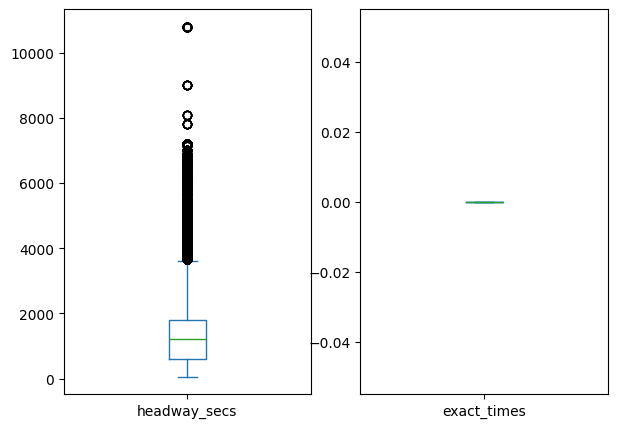

<Figure size 640x480 with 0 Axes>

In [46]:
#necessário converter o headway de string para int primeiro
df = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/frequencies.csv")
df_freq_limpo = df
df_freq_limpo['headway_secs'] = df['headway_secs'].astype(int)
caminho_freq_limpo = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados tratados/freq_limpo.csv"
df_freq_limpo.to_csv(caminho_freq_limpo, index=False)

df.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 8))
plt.figure()



Temos poucos valores distantes próximos a 10.000 segundos. Isso equivale a aproximadamente 3 horas. Provavelmente são ônibus que funcionam de madrugada ou que possuem poucos horários por dia. Não temos outliers que necessitem ser excluídos.

# Adição da duração da viagem no dataset
Abaixo, vou incluir a coluna `duracao_viagem` na tabela `viagem_informada.csv`. Em seguida, realizarei a análise buscando por outliers (viagens excessivamente longas ou curtas demais).

In [47]:
#criando cópia na memória
df = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/br_rj_riodejaneiro_viagem_zirix-20260430T211251Z-3-001/br_rj_riodejaneiro_viagem_zirix/viagem_informada.csv")
df_viagens_limpo = df.copy()

#convertendo os valores de data, hora, minuto e segundo de string para datetime64
df_viagens_limpo['datetime_chegada'] = pd.to_datetime(df_viagens_limpo['datetime_chegada'])
df_viagens_limpo['datetime_partida'] = pd.to_datetime(df_viagens_limpo['datetime_partida'])

#incluindo a coluna duracao_viagem_minutos nesse dataset
df_viagens_limpo['viagem_minutos'] = (df_viagens_limpo['datetime_chegada'] - df_viagens_limpo['datetime_partida']).dt.total_seconds() / 60
display(df_viagens_limpo.head())



,data,datetime_partida,datetime_chegada,datetime_processamento,datetime_captura,id_veiculo,trip_id,route_id,shape_id,servico,sentido,id_viagem,versao,datetime_ultima_atualizacao,viagem_minutos
0,2026-02-25,2026-02-25 06:01:01,2026-02-25 07:03:31,2026-02-25 07:03:33,2026-02-25 07:10:00,A71544,NaN,O0409AAA0A,gnoq,409,Ida,A71544_409_I_gnoq_20260225060101,26a029cc24759a6b0acbfc87d7999e9b7f78db7c,2026-02-28 01:32:30.297869,62.500000
1,2024-12-08,2024-12-08 18:23:39,2024-12-08 19:34:38,2024-12-08 19:34:40,2024-12-08 19:40:00,B10003,NaN,186,421,901,Ida,B10003_901_I_421_20241208182339,0797b1e917d2ed2d50489a35abd2b87dcab54b55,2024-12-10 01:34:25.331602,70.983333
2,2025-09-19,2025-09-19 06:41:53,2025-09-19 08:27:23,2025-09-19 08:27:25,2025-09-19 08:40:00,D13012,NaN,O0383AAA0A,34402958-de24-498e-b913-3f70f5311747,383,Volta,D13012_383_V_34402958-de24-498e-b913-3f70f5311...,06f003ebcace75a8702b05d063933a3ac6edc0f8,2025-09-26 01:32:16.328995,105.500000
3,2025-06-27,2025-06-27 04:53:31,2025-06-27 05:11:55,2025-06-27 05:11:58,2025-06-27 05:20:00,A48056,NaN,O0202AAA0A,1760,202,Ida,A48056_202_I_1760_20250627045331,477e243683cf4516bd39ad4ee8ff21793b78279c,2025-07-02 01:32:34.960347,18.400000
4,2025-02-19,2025-02-19 07:15:43,2025-02-19 09:27:43,2025-02-19 20:17:14,2025-02-19 20:30:00,C47638,NaN,O0390AAA0A,5au5,390,Ida,C47638_390_I_5au5_20250219071543,8b2a8320de08cc624e12dbbd49f8e02da750444f,2025-02-28 01:34:03.91567,132.000000


## Quantidade de viagens por linha
Será que essa distribuição é desigual Temos linhas com poucas entradas de viagens?

O código abaixo identifica as linhas que possuem menos do que 200 viagens registradas e exclui-as do dataset. Perdemos apenas 5% das entradas, que estavam associadas a aproximadamente 40% das linhas.

O modelo vai perder a capacidade de realizar previsões com essas linhas, porém, com o dataset atual essa medida foi necessária para evitar overfitting

**Altere o limite corte para verificar quantas linhas possuem menos ou mais do que esse número de viagens**

Total de linhas:549
Linhas com menos de 200 viagens: 235
Linhas com mais ou igual de 200 viagens: 314


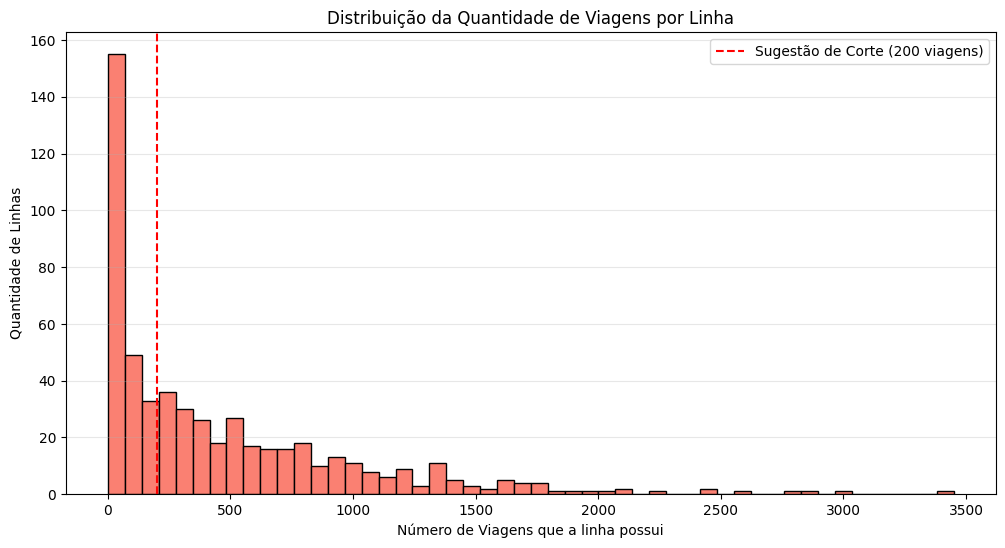

In [48]:
# 1. Calculamos a contagem para cada serviço
contagem_viagens = df_viagens_limpo['servico'].value_counts()
lista_linhas = df_viagens_limpo['servico'].unique()

print("Total de linhas:" + str(len(lista_linhas)))

# 2. Criamos o histograma dessa contagem
plt.figure(figsize=(12, 6))
plt.hist(contagem_viagens, bins=50, color='salmon', edgecolor='black')

# Adicionando uma linha vertical para facilitar a identificaç~ao da quantidade de linhas com menos de x viagens
limite_corte = 200
plt.axvline(limite_corte, color='red', linestyle='--', label='Sugestão de Corte ('+str(limite_corte)+' viagens)')
print("Linhas com menos de "+str(limite_corte)+" viagens: "+str( (contagem_viagens < limite_corte).sum() ))
print("Linhas com mais ou igual de "+str(limite_corte)+" viagens: "+str( (contagem_viagens >= limite_corte).sum() ))

plt.title('Distribuição da Quantidade de Viagens por Linha')
plt.xlabel('Número de Viagens que a linha possui')
plt.ylabel('Quantidade de Linhas')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# DELETANDO AS VIAGENS DAS LINHAS QUE POSSUEM MENOS DE "LIMITE_CORTE" VIAGENS
linhas_aprovadas = contagem_viagens[contagem_viagens >= 200].index
df_viagens_limpo = df_viagens_limpo[df_viagens_limpo['servico'].isin(linhas_aprovadas)].copy()

In [49]:
# Quanto do volume total (em %) essas linhas com poucos dados de viagens representam?
viagens_pequenas = contagem_viagens[contagem_viagens < limite_corte].sum()
total_geral = contagem_viagens.sum()

print(f"Total de viagens: {total_geral} viagens")
print(f"Quantidade de viagens de linhas pequenas: {viagens_pequenas} viagens")
print(f"Porcentagem equivalente do total de dados: {(viagens_pequenas / total_geral) * 100:.2f}%")

Total de viagens: 256725 viagens
Quantidade de viagens de linhas pequenas: 12923 viagens
Porcentagem equivalente do total de dados: 5.03%


# Análise Exploratória de Dados Inicial

## Duração das viagens
 É possível ver que existem viagens com duração menor que 10 minutos sendo a menor viagem com duração negativa e a maior com mais de 12 horas (outlier). Temos que excluir essas viagens "extremas" do dataset

      viagem_minutos
count      243802.00
mean           59.35
std            29.46
min            -0.50
25%            37.50
50%            57.47
75%            77.45
max           728.12


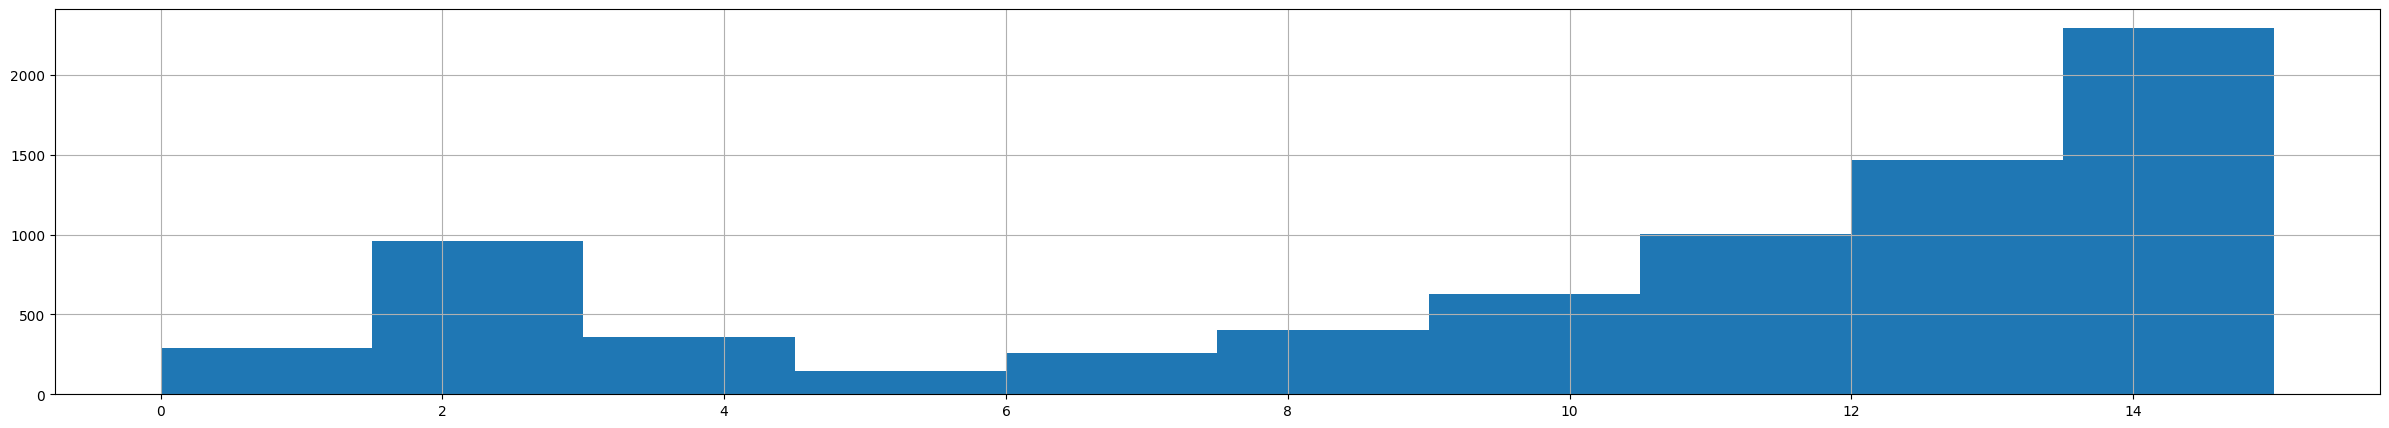

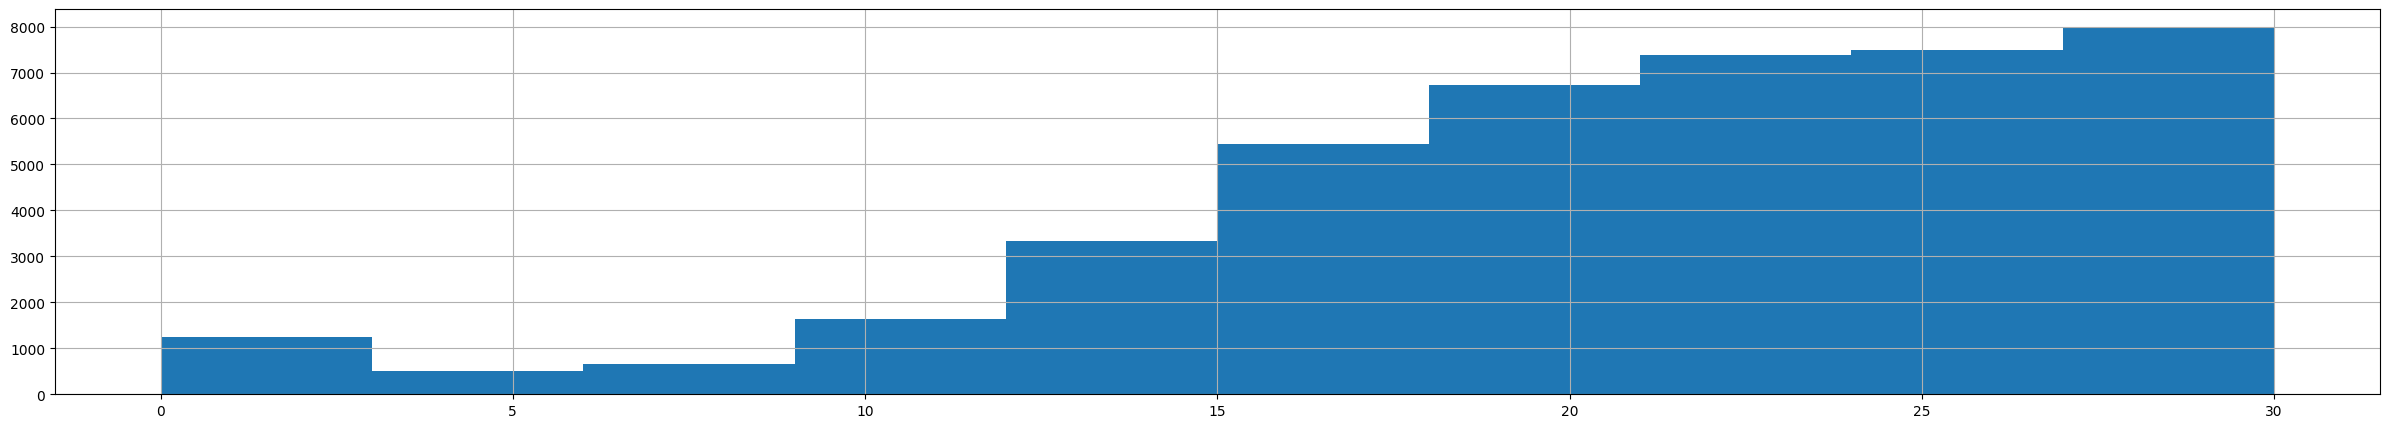

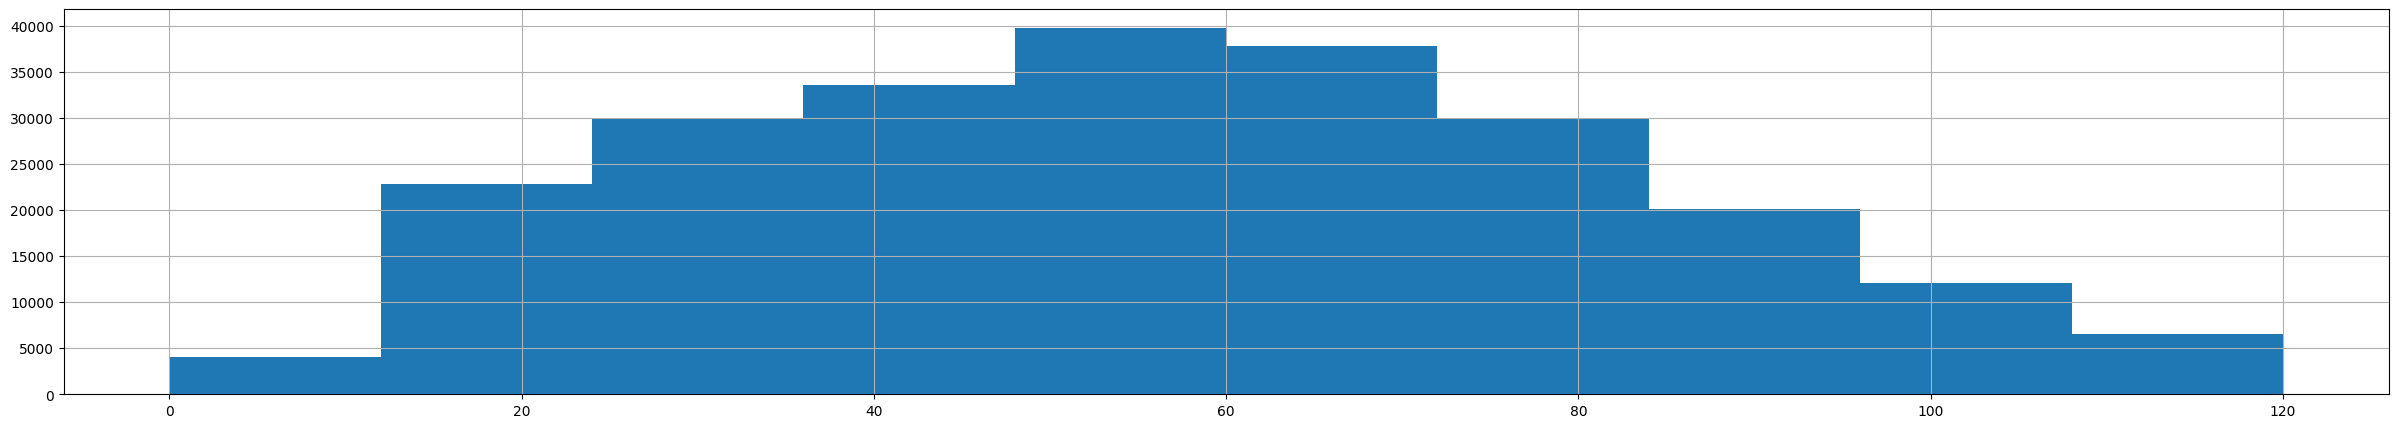

<Figure size 640x480 with 0 Axes>

In [50]:

#buscando por outliers
df_viagens_limpo['viagem_minutos'].hist(figsize=(30, 5), range=(0,15))
plt.figure()
df_viagens_limpo['viagem_minutos'].hist(figsize=(30, 5), range=(0,30))
plt.figure()
df_viagens_limpo['viagem_minutos'].hist(figsize=(30, 5), range=(0,120))
plt.figure()

#técnica proposta pela monitora na aula de tratamento de dados. Vai dar os valores minimos, médios e máximos das durações da viagem
print(df_viagens_limpo[['servico', 'viagem_minutos']].describe().apply(lambda s: s.apply('{0:.2f}'.format)))




In [51]:
# Agrupamos por serviço e descrevemos a coluna de minutos
resumo_por_linha = df_viagens_limpo.groupby('servico')['viagem_minutos'].describe()

# Formatamos para 2 casas decimais para facilitar a leitura
print(resumo_por_linha.apply(lambda s: s.apply('{0:.2f}'.format)))

           count   mean    std    min    25%    50%    75%     max
servico                                                           
007       465.00  32.06  10.62  16.73  26.45  30.53  36.08  194.67
014       287.00  23.65   4.29   0.00  21.00  24.00  26.38   39.00
100      2103.00  43.66  10.78  17.00  36.36  43.50  50.24  100.25
104       664.00  85.28  22.41  11.00  69.73  84.23  98.06  165.02
107       918.00  40.87  16.22  15.95  32.38  38.50  48.79  378.92
...          ...    ...    ...    ...    ...    ...    ...     ...
SV917     366.00  80.18  16.59  40.00  68.95  78.89  91.07  137.00
SV922     271.00  31.82   5.20  17.00  28.01  31.05  35.03   47.17
SVA665    414.00  74.82  23.63  41.53  58.50  68.00  86.11  264.87
SVB665    392.00  74.72  21.15  12.62  60.00  71.23  86.51  149.67
SVB685    259.00  79.21  16.70  52.67  71.22  78.28  85.74  280.63

[314 rows x 8 columns]


## Identificando outliers: viagens muito rápidas ou muito lentas.

Para identificar esses outliers, utilizarei a função `outlier`, definida abaixo. Uma função semelhante foi apresentada na aula de Tratamento de Dados da Analytica, mas optei por essa pois os dados de trânsito não são simétricos. Utilizar IQR não foi eficiente.

Para o nosso contexto, precisamos agrupar o número de viagens por linhas de ônibus.


Inicialmente,excluí todas as viagens mais curtas que 10 minutos e tentei filtrar usando intervalos interquartis e medianas, porém, isso acabou permitindo viagens muito rápidas/curtas ou então excluindo viagens rápidas.

Como melhoria, decidi mudar de método e cruzar a duração do percurso com a distância percorrida, fixando uma velocidade média mínima (5km/h) e máxima(65km/h) e, assim, filtrar os ônibus que não possuírem uma velocidade média dentro do intervalo estipulado. Esses serão tratados como outliers, representando medições erradas ou situações fora do comum nas vias.(https://www.rio.rj.gov.br/web/guest/exibeconteudo?id=1893686 ).

In [52]:
def outlier(df, coluna):

  p10 = df[coluna].quantile(0.10)
  p90 = df[coluna].quantile(0.90)
  mediana = df[coluna].median()

  #30% da mediana é tolerável. Se a mediana for 20km/h, aceita até 6km/h.
  limite_inferior = mediana * 0.3

  # Toda a linha tem tolerância para chegar a pelo menos 50 km/h (madrugadas/vias livres).
  # Se for um BRT rápido (onde P90*1.5 dá mais de 50), ele aceita o maior valor, travado no máximo físico de 65 km/h.
  limite_superior = min(max(p90 * 1.8, 50.0), 65.0)

  df_bom = df[(df[coluna] >= limite_inferior) & (df[coluna] <= limite_superior) | df[coluna].isna()].copy()

  # Teste 1: Velocidade media

  # Isola quem são os outliers para podermos imprimir os detalhes
  df_ruim = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

  if len(df_ruim) > 0:
      print(f"\n{len(df_ruim)} OUTLIER(S) ENCONTRADO(S) NA LINHA '{df['servico'].iloc[0]}'. Viagens válidas: '{len(df_bom)}'")

      # Faz um loop pelos outliers para mostrar o valor e o intervalo
      cont = 0
      for index, row in df_ruim.iterrows():
          valor_exato = row[coluna]
          print(f"   -> Viagem de {valor_exato:.2f} hm/h | (Intervalo aceitável era de {limite_inferior:.2f} a {limite_superior:.2f})")
          cont += 1
          if(cont >5):
            cont = 0
            break

  return df_bom

def limpar_outlier_duracao_viagem(df):
  df_limpo = []
  linhas_onibus = df['servico'].unique()

  for linha in linhas_onibus:
    df_linha = df[df['servico'] == linha].copy()
    df_sem_outlier = outlier(df_linha, 'veloc_media_kmh')
    df_limpo.append(df_sem_outlier)

  df_final = pd.concat(df_limpo, ignore_index=True)
  return df_final

cont_removidas = 0
cont_total = len(df_viagens_limpo)

df_ordem_servico = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/ordem_servico.csv")
#remove duplicatas e filtra a parte util
df_ordem_servico = df_ordem_servico[['servico', 'extensao_ida', 'extensao_volta']].drop_duplicates(subset=['servico'])

#cruza os dados
df_viagens_limpo = df_viagens_limpo.merge(df_ordem_servico, on='servico', how='left')

# Definimos a distância correta da viagem baseada na coluna 'sentido' (0 = Ida, 1 = Volta)
df_viagens_limpo['distancia_km'] = np.where(
    df_viagens_limpo['sentido'] == 0,
    df_viagens_limpo['extensao_ida'],
    df_viagens_limpo['extensao_volta']
)

# Calculamos a velocidade média em km/h
df_viagens_limpo['veloc_media_kmh'] = df_viagens_limpo['distancia_km'] / (df_viagens_limpo['viagem_minutos'] / 60)

# remove viagens sem valor de velocidade
cont_removidas = df_viagens_limpo['veloc_media_kmh'].isna().sum()
print("Viagens com velocidade nula - " + str(cont_removidas))
df_viagens_limpo = df_viagens_limpo.dropna(subset=['veloc_media_kmh']).copy()

#excluindo casos extremos de velocidade
vel_minima = 5.0
vel_maxima = 65.0
df_valido = (df_viagens_limpo['veloc_media_kmh'] >= vel_minima) & (df_viagens_limpo['veloc_media_kmh'] <= vel_maxima)



# Atualiza o DataFrame APENAS com os dados fisicamente possíveis
df_viagens_limpo = df_viagens_limpo[df_valido].copy()

print(f"Viagens com velocidade absurda (fora da faixa 5 a 65 km/h): {cont_total - cont_removidas - len(df_viagens_limpo)}")
cont_removidas += cont_total - cont_removidas - len(df_viagens_limpo)

df_viagens_tratado = limpar_outlier_duracao_viagem(df_viagens_limpo)






Viagens com velocidade nula - 8454
Viagens com velocidade absurda (fora da faixa 5 a 65 km/h): 12617

1 OUTLIER(S) ENCONTRADO(S) NA LINHA '870'. Viagens válidas: '459'
   -> Viagem de 5.44 hm/h | (Intervalo aceitável era de 6.55 a 50.00)

4 OUTLIER(S) ENCONTRADO(S) NA LINHA '990'. Viagens válidas: '309'
   -> Viagem de 7.43 hm/h | (Intervalo aceitável era de 7.95 a 63.32)
   -> Viagem de 7.41 hm/h | (Intervalo aceitável era de 7.95 a 63.32)
   -> Viagem de 7.30 hm/h | (Intervalo aceitável era de 7.95 a 63.32)
   -> Viagem de 6.49 hm/h | (Intervalo aceitável era de 7.95 a 63.32)

1 OUTLIER(S) ENCONTRADO(S) NA LINHA '878'. Viagens válidas: '1326'
   -> Viagem de 61.25 hm/h | (Intervalo aceitável era de 6.85 a 60.35)

1 OUTLIER(S) ENCONTRADO(S) NA LINHA '209'. Viagens válidas: '759'
   -> Viagem de 56.00 hm/h | (Intervalo aceitável era de 5.33 a 50.00)

1 OUTLIER(S) ENCONTRADO(S) NA LINHA '415'. Viagens válidas: '1329'
   -> Viagem de 53.70 hm/h | (Intervalo aceitável era de 6.33 a 53.49)

In [53]:
display(df_viagens_limpo.head())

,data,datetime_partida,datetime_chegada,datetime_processamento,datetime_captura,id_veiculo,trip_id,route_id,shape_id,servico,sentido,id_viagem,versao,datetime_ultima_atualizacao,viagem_minutos,extensao_ida,extensao_volta,distancia_km,veloc_media_kmh
0,2026-02-25,2026-02-25 06:01:01,2026-02-25 07:03:31,2026-02-25 07:03:33,2026-02-25 07:10:00,A71544,NaN,O0409AAA0A,gnoq,409,Ida,A71544_409_I_gnoq_20260225060101,26a029cc24759a6b0acbfc87d7999e9b7f78db7c,2026-02-28 01:32:30.297869,62.500000,18.905,18.904,18.904,18.147840
1,2024-12-08,2024-12-08 18:23:39,2024-12-08 19:34:38,2024-12-08 19:34:40,2024-12-08 19:40:00,B10003,NaN,186,421,901,Ida,B10003_901_I_421_20241208182339,0797b1e917d2ed2d50489a35abd2b87dcab54b55,2024-12-10 01:34:25.331602,70.983333,25.033,26.419,26.419,22.331158
2,2025-09-19,2025-09-19 06:41:53,2025-09-19 08:27:23,2025-09-19 08:27:25,2025-09-19 08:40:00,D13012,NaN,O0383AAA0A,34402958-de24-498e-b913-3f70f5311747,383,Volta,D13012_383_V_34402958-de24-498e-b913-3f70f5311...,06f003ebcace75a8702b05d063933a3ac6edc0f8,2025-09-26 01:32:16.328995,105.500000,33.307,33.623,33.623,19.122085
3,2025-06-27,2025-06-27 04:53:31,2025-06-27 05:11:55,2025-06-27 05:11:58,2025-06-27 05:20:00,A48056,NaN,O0202AAA0A,1760,202,Ida,A48056_202_I_1760_20250627045331,477e243683cf4516bd39ad4ee8ff21793b78279c,2025-07-02 01:32:34.960347,18.400000,8.863,10.404,10.404,33.926087
4,2025-02-19,2025-02-19 07:15:43,2025-02-19 09:27:43,2025-02-19 20:17:14,2025-02-19 20:30:00,C47638,NaN,O0390AAA0A,5au5,390,Ida,C47638_390_I_5au5_20250219071543,8b2a8320de08cc624e12dbbd49f8e02da750444f,2025-02-28 01:34:03.91567,132.000000,31.888,31.158,31.158,14.162727


# Limpeza final da tabela: Conversão dos valores para tipos adequados para um algoritmo de ML baseado em árvores

Segundo [blog técnico da NVIDIA](https://developer.nvidia.com/blog/three-approaches-to-encoding-time-information-as-features-for-ml-models/), "when using non-linear models such as decision trees (or ensembles of thereof), we do not explicitly encode features such as month number or day of the year as dummies. Those models are capable of learning non-monotonic relationships between ordinal input features and the target".

Logo, não precisaremos utilizar técnicas de OHC e dummy variables

Assim, uma ideia para as colunas que alimentarão o modelo pode ser:
1. `mês_viagem`:  valor inteiro de 1 a 12
1. `dia_viagem`: valor numerico (1 a 30) do dia da viagem.
2. `dia_semana`:  valor inteiro de 1 a 7 (segunda a domingo)
1. `eh_feriado`: 0 se for feriado e 1 se nao
2. `hora_partida`:  valor inteiro representando a quantidade de minutos que se passaram desde meia noite (0 ate 1429)
2. `duracao`:  valor inteiro representando a quantidade de minutos que se passaram desde meia noite (0 ate 1429) **VALOR QUE SERA PREVISTO**
3. `linha`: numero representando a linha. sera necessário fazer um hashmap entre a string da linha (ex. "SN324) e um numero inteiro representando-a
3. `sentido`: Indica se a viagem estava indo (0) ou voltando (1)

Abaixo, temos o algoritmo que estrutura todos esses valores em uma única tabela:




In [60]:
df_final = df_viagens_limpo.copy()

# excluindo colunas desnecessarias
lista_dropar = ['data', 'datetime_chegada', 'datetime_processamento', 'datetime_captura', 'id_veiculo', 'trip_id', 'route_id', 'shape_id', 'id_viagem', 'versao', 'datetime_ultima_atualizacao', 'extensao_ida', 'extensao_volta', 'distancia_km', 'veloc_media_kmh']
df_final = df_final.drop(lista_dropar, axis=1)

df_final = df_final.rename(columns={
    'viagem_minutos': 'duracao'
})

#Passo 1: Desmembrar a coluna de datetime_partida em mes, dia, hora, dia da semana e feriado

df_final['mes_viagem'] = df_final['datetime_partida'].dt.month
df_final['dia_viagem'] = df_final['datetime_partida'].dt.day
df_final['hora_partida'] = (df_final['datetime_partida'].dt.hour * 60) + df_final['datetime_partida'].dt.minute
#Dia da Semana (0 = Segunda-feira, 6 = Domingo)
df_final['dia_semana'] = df_final['datetime_partida'].dt.dayofweek

#adicionando feriados
data_feriados = holidays.country_holidays('BR', subdiv='RJ')
df_final['eh_feriado'] = df_final['datetime_partida'].dt.date.isin(data_feriados).astype(int)

df_final = df_final.drop('datetime_partida', axis=1)

display(df_final.iloc[100:1000])

#salvando dataframe
caminho_df_final = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados tratados/df_final.csv"
df_final.to_csv(caminho_df_final, index=False)


,servico,sentido,duracao,mes_viagem,dia_viagem,hora_partida,dia_semana,eh_feriado
107,850,Ida,30.050000,6,10,634,1,0
108,871,Ida,58.500000,12,19,1039,4,0
109,497,Volta,68.500000,1,22,795,2,0
110,SV474,Ida,53.000000,8,27,932,2,0
112,863,Ida,28.016667,4,30,931,2,0
...,...,...,...,...,...,...,...,...
1085,746,Ida,28.550000,3,31,211,0,0
1086,302,Ida,108.600000,1,30,964,3,0
1087,606,Ida,52.366667,4,16,1261,2,0
1088,426,Volta,71.500000,1,8,547,3,0
